# AG-HYPOPT · Trial 05

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Campaign state at trial_05. Four trials recorded:

- trial_01 = target, h_f 5.349, h_s 7.652 -> 0.0837.
- trial_02 = sim, h_f 5.308, h_s 3.060 -> 0.1249.
- trial_03 = power, h_f 8.658, h_s 4.220 -> 0.1541.
- trial_04 = target, h_f 9.821, h_s 2.920 -> 0.0926.

Current best is trial_01 (0.0837); exp6 reference target, h_f 4.0, h_s 3.675 -> 0.0803. Full ranking
so far: target 4.0 (0.0803) < target 5.35 (0.0837) < target 9.82 (0.0926) < sim (0.1249) < power
(0.1541). Two facts stand out: (i) the target rule is the best of the three by a wide margin; (ii) on the
target rule the objective rises monotonically as h_f increases above exp6's 4.0, so the promising
untested direction is BELOW h_f ~4, which no trial has yet explored for the target rule.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_05'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (4/5 trials)
ID |     ei | params
 1 |      - | {"bandwidth_rule": "power", "h_f_scale": 9.887348687101431, "h_s_scale": 6.668581171463562}
 2 |      - | {"bandwidth_rule": "power", "h_f_scale": 4.143815180969558, "h_s_scale": 1.5932377261982207}
 3 |      - | {"bandwidth_rule": "target", "h_f_scale": 5.493205259619986, "h_s_scale": 1.4980271329268968}
 4 |      - | {"bandwidth_rule": "sim", "h_f_scale": 1.5363348179988487, "h_s_scale": 11.990937265715786}
 5 |      - | {"bandwidth_rule": "target", "h_f_scale": 3.579612218368063, "h_s_scale": 5.784423074476562}
 6 |      - | {"bandwidth_rule": "sim", "h_f_scale": 11.71604812585181, "h_s_scale": 10.874453689194036}
 7 |      - | {"bandwidth_rule": "power", "h_f_scale": 5.31645130768256, "h_s_scale": 6.423253206049169}
 8 |      - | {"bandwidth_rule": "power", "h_f_scale": 8.443582870141727, "h_s_scale": 1.6688298425386168}
 9 |      - | {"bandwidth_rule": "power", "h_f_scale": 3.985967649831117, "h_s_scale": 10.67616290

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

The evidence now points in a specific direction. The target rule dominates (0.0803-0.0926 vs 0.1249 for
sim and 0.1541 for power), and within the target rule the objective grows with h_f (0.0803 @4.0, 0.0837
@5.35, 0.0926 @9.82). Every target trial so far sits at or above exp6's h_f = 4.0, so the untested and
now most promising direction is a target configuration BELOW h_f = 4.

The proposals contain two `target` candidates: #3 (h_f 5.49, h_s 1.50) and #5 (h_f 3.58, h_s 5.78).
Candidate #3 is again above 4 and so re-treads the region just shown to be on the wrong side of the
optimum. Candidate #5 (h_f 3.58) is the single proposal that tests the target rule below exp6's 4.0 - it
directly establishes whether the optimum is at 4 or further down, and whether that is where the extra
headroom lives. The remaining proposals are sim/power, already argued against.

I choose candidate 5 (target, h_f_scale 3.580, h_s_scale 5.784).


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 5            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'bandwidth_rule': 'target', 'h_f_scale': 3.579612218368063, 'h_s_scale': 5.784423074476562}
Running  1nW Trans05 ... 

μ 9.39 -> 6.14 | γ 8.5 -> 5.97 | NLL 0.21


Running  1nW Trans20 ... 

μ 17.32 -> 27.75 | γ 8.5 -> 5.49 | NLL 0.57


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 62.78 | γ 14.1 -> 14.05 | NLL 0.67


Running 3nW Trans100 ... 

μ 175.71 -> 98.44 | γ 14.1 -> 13.81 | NLL 0.67



Total: 7.3 min


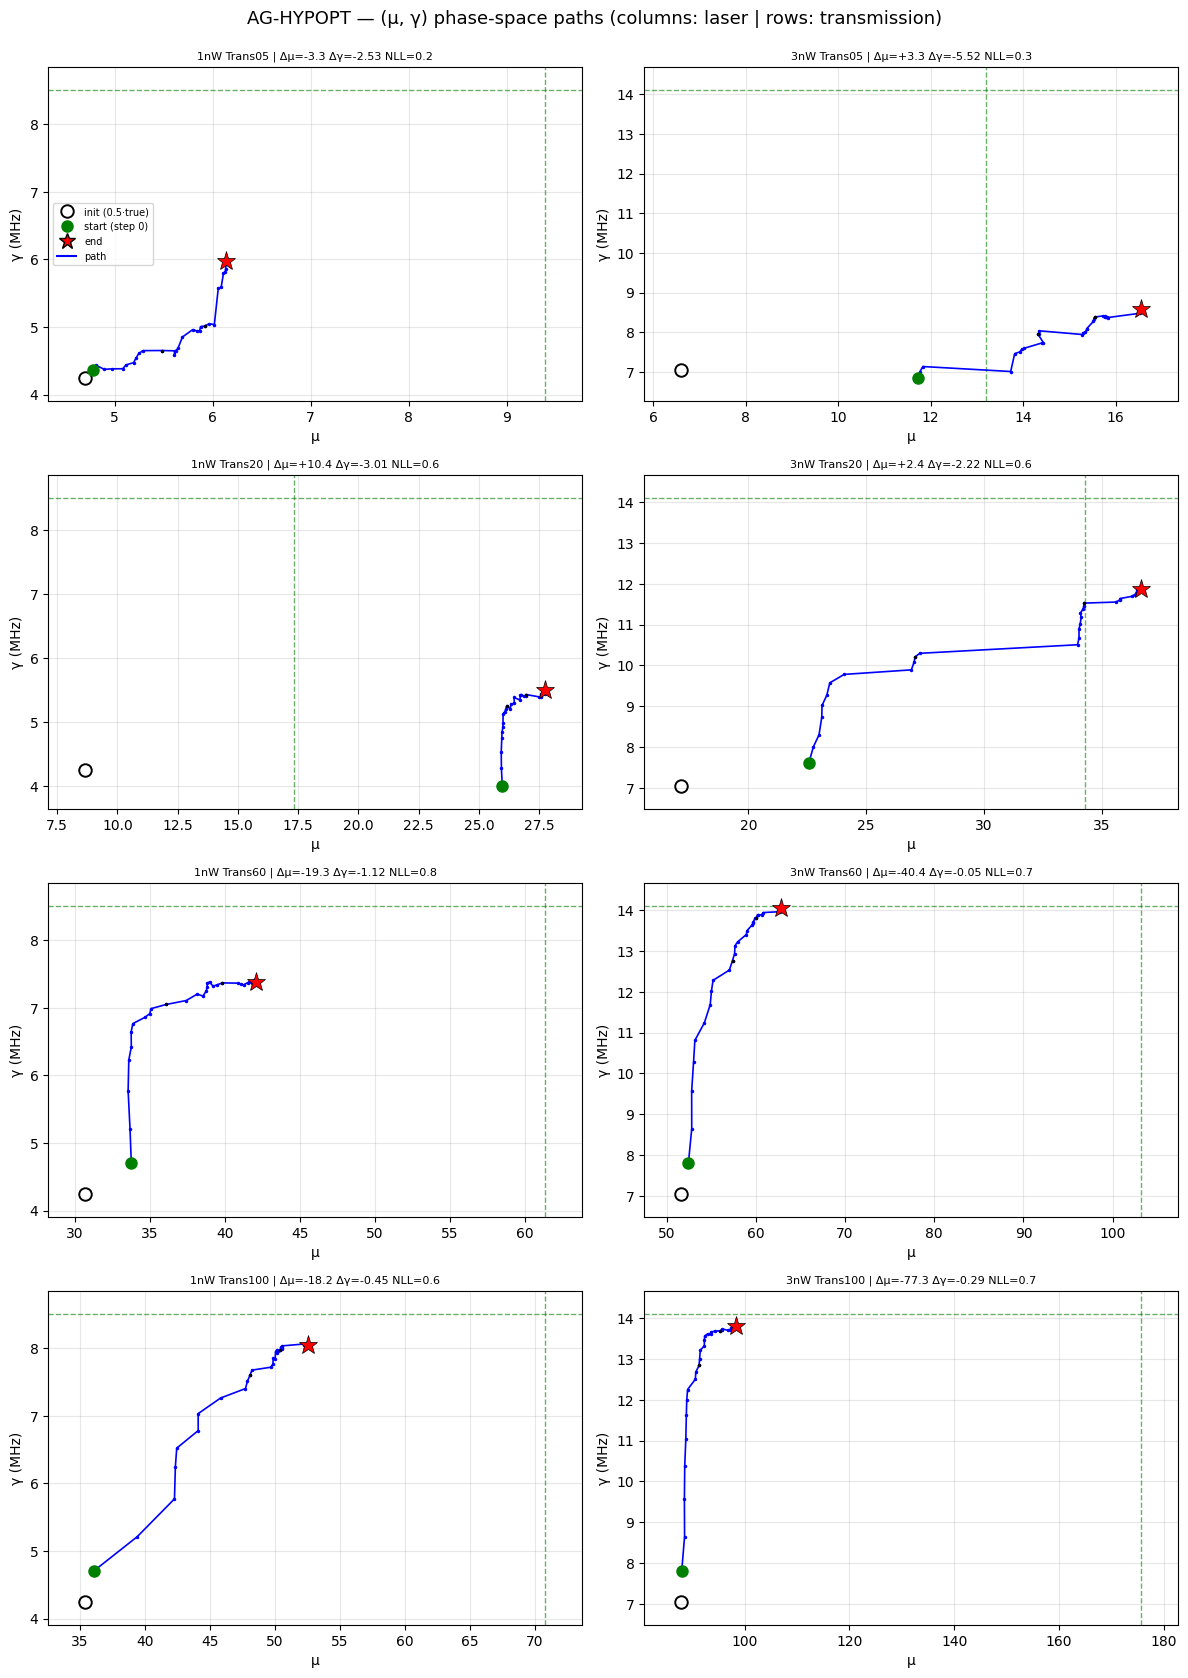

trial finished in 7.3 min
objective = 0.0818 ± 0.0239
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    6.14   -34.6 |     8.50    5.97   -29.7
1nW Trans20       17.32   27.75   +60.2 |     8.50    5.49   -35.4
1nW Trans60       61.37   42.09   -31.4 |     8.50    7.38   -13.2
1nW Trans100       70.82   52.60   -25.7 |     8.50    8.05    -5.3
3nW Trans05       13.20   16.55   +25.3 |    14.10    8.58   -39.1
3nW Trans20       34.28   36.68    +7.0 |    14.10   11.88   -15.7
3nW Trans60      103.20   62.78   -39.2 |    14.10   14.05    -0.4
3nW Trans100      175.71   98.44   -44.0 |    14.10   13.81    -2.0

weighted objective (T-graded, cap=1.0) = 0.0818 | diverged cells: 0
μ: RMSE 32.488 (rel 36.5%, bias -17.781) | γ: RMSE 2.557 (rel 22.7%, bias -1.898)


TypeError: unsupported operand type(s) for -: 'str' and 'str'

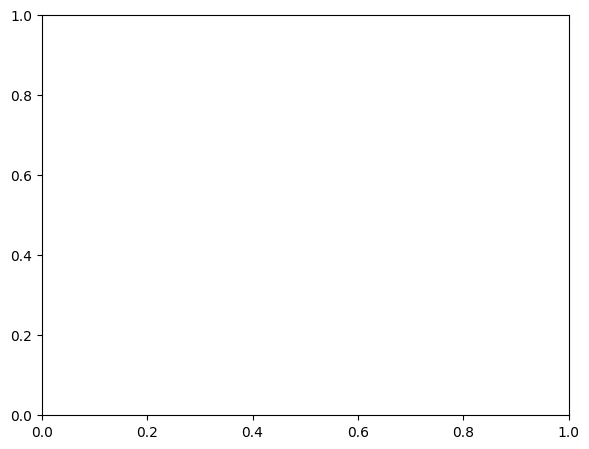

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Objective = 0.0818 ± 0.0239, gamma finite on all 8 cells, diverged cells: 0. Config: bandwidth_rule =
target, h_f_scale = 3.580, h_s_scale = 5.784. This is the best campaign result so far, edging past
trial_01 (0.0837), though still just above exp6's headline 0.0803.

Per-cell: mu is now mixed-sign rather than uniformly low (1nW Trans20 +60.2 %, 3nW Trans05 +25.3 %,
3nW Trans20 +7.0 %; the rest -25 to -44 %), gamma is underestimated on all 8 cells but the high-T ones
are nearly exact (3nW Trans60 -0.4 %, 3nW Trans100 -2.0 %, 1nW Trans100 -5.3 %). The remaining error
sits in the low-count cells, as in every trial.

This trial was specifically placed BELOW exp6's h_f = 4.0 (h_f 3.58), the previously untested direction,
and it improved on the campaign best. The target-rule trend in h_f is therefore not monotone-increasing
over the whole range: 0.0803 @ h_f 4.0 (exp6), 0.0818 @ 3.58, 0.0837 @ 5.35, 0.0926 @ 9.82. The optimum
sits around h_f ~ 3.6-4.0, with the objective rising on both sides - consistent with exp6's optimum
having been essentially the true target-rule optimum, but with a shallow improvement still available just
below 4.0. Overall ranking: target 3.58 (0.0818) < target 4.0 / exp6 (0.0803) < target 5.35 (0.0837)
< target 9.82 (0.0926) < sim (0.1249) < power (0.1541).

Execution note: same trailing `plot_parallel` diagnostic TypeError; objective computed and printed first,
so the trial stands. No rerun.

**Summary:** Trial 5 (target rule, h_f 3.580, h_s 5.784) scores objective 0.0818 ± 0.0239, a new campaign best, confirming the target rule is better just below exp6's h_f = 4.0 than above it.
**Key insight:** Placing the target rule below exp6's bound (h_f 5.35 -> 3.58) improves the objective (0.0837 -> 0.0818), so the target-rule optimum lies around h_f ~3.6-4.0 and the exp6 ceiling was close to optimal for this rule.

Notes for Anuar (optional, not acted on): the best points of the target rule (h_f 3.6-4.0) also carry
h_s ~4-6, so the sigma-channel coefficient is less well pinned than h_f; a finer 2-D refinement around
(h_f 3.5-4.5, h_s 4-6) is likely where any further gain for this rule would come from.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 5 (target rule, h_f 3.580, h_s 5.784) scores objective 0.0818 ± 0.0239, a new campaign best, confirming the target rule is better just below exp6's h_f = 4.0 than above it."      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "Placing the target rule below exp6's bound (h_f 5.35 -> 3.58) improves the objective (0.0837 -> 0.0818), so the target-rule optimum lies around h_f ~3.6-4.0 and the exp6 ceiling was close to optimal for this rule."  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_05 | current best: trial_05


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_06.ipynb. Open it and follow its cells from the top.
